# Real data: human calibration --- Figures 4, 10, 11, 12

Study 3, judge panels across budget regimes (appendix G.4.2), plus the main-text calibration figure.
Three sweeps drawn on the same 3 x 3 grid (datasets x judge panels `small6` / `large6` / `all`):

| Figure | Sweep | Fixed |
|---|---|---|
| `fig_panel_human_budget` (Fig. 10) | human budget $n_H$ | as-collected LLM data |
| `fig_panel_llm_budget` (Fig. 11) | LLM budget $n_L$ | $n_H = 300 / 80 / 60$ |
| `fig_panel_intermediate_llm` (Fig. 12) | human budget $n_H$ | $n_L = 2{,}000 / 160 / 100$ |

Metric: excess held-out log loss, the version used in the manuscript.
Kendall's $\tau$ is recorded per cell as well and is the metric of Figure 4; `show(name, metrics=METRIC)` draws both.
Bands are $\pm1.96$ Monte Carlo s.e. over 50 splits.


In [1]:

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import NullFormatter, ScalarFormatter

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

# Loaders only -- every figure of this study is drawn in this notebook, not in a script.
from experiments.real_data.panel_budget import (  # noqa: E402
    ATC, CALIBRATION_DATASET, CALIBRATION_PANEL, INTERMEDIATE_NL, NH, PANELS,
    calibration_rows, human_exists_budgets, intermediate_data, panel_budget_data,
)
from experiments.style import GRID, LABEL, RCPARAMS, STYLE, DATASET_LABEL, mark_better  # noqa: E402

FIG_DIR = REPO / "figures"
FIG_DIR.mkdir(exist_ok=True)

summary = panel_budget_data()                    # robustness rows; asserts all 50 seeds per cell
intermediate, seeds = intermediate_data()        # results/intermediate_budget, with its own checks
print(f"{len(summary)} budget/llm_budget rows, {len(intermediate)} intermediate rows ({seeds} seeds)")

306 budget/llm_budget rows, 171 intermediate rows (50 seeds)


## Figure code

The 3 x 3 appendix grid and the main-text calibration panel are both defined here: `experiments/real_data/panel_budget.py` only loads and aggregates the stored result rows, so this notebook is the single source of every figure in this study.


In [2]:

PANEL_TITLE = ["small panel (36.5B)", "large panel (203B)", "full panel (21 judges)"]
XTICKS = {"arena_33k": [50, 200, 800, 3200], "mt_bench": [20, 80, 320], "pandalm": [20, 80, 320]}

# Names, colours and dashes come from the shared method panel of experiments/style.py, so this
# study draws the same three estimators the simulation and robustness studies do. human_only is
# first and is dropped where it is absent.
METHOD_KEYS = ["human_only", "consensus_cal", "dial_mu"]
METHODS = [(k, LABEL[k], STYLE[k]["color"], STYLE[k]["ls"], STYLE[k]["marker"]) for k in METHOD_KEYS]

# Both metrics are recorded per cell by every runner; `excess` is minimized, `tau` maximized, so
# they need different y limits but nothing else.
METRIC = {
    "excess": dict(value="excess", err="se", label="excess held-out log loss"),
    "tau": dict(value="tau", err="tau_se", label=r"Kendall's $\tau$, held-out ranking"),
}


def panel_grid(rows, x_column, ylabel, xlabel, methods, flat=(), titles=PANEL_TITLE,
               xticks=True, metric="excess"):
    """The shared 3 x 3 figure: one row per dataset, one column per judge panel.

    `metric` selects the plotted column through `METRIC`: 'excess' (held-out log loss, lower is
    better, y starts at zero) or 'tau' (Kendall's tau against the held-out human ranking, higher
    is better, y limits follow the data and stop at 1). `flat` names methods drawn as a
    horizontal reference line, their value not varying along that sweep's x axis. The y axis is
    shared within a row; for log loss it excludes Human from its upper limit, which is off the
    chart at the smallest budgets.
    """
    value, err = METRIC[metric]["value"], METRIC[metric]["err"]
    fig, axes = plt.subplots(3, 3, figsize=(7.4, 6.6), sharey="row")
    for i, ds in enumerate(NH):
        row = rows[rows.dataset == ds]
        if metric == "excess":
            scaled = row[row.method != "human_only"]
            limits = (-.002, max(.01, float((scaled[value] + 1.96 * scaled[err]).max()) * 1.08))
        else:
            lo = float((row[value] - 1.96 * row[err]).min())
            hi = float((row[value] + 1.96 * row[err]).max())
            pad = .04 * max(hi - lo, .05)
            limits = (lo - pad, min(1.0, hi + pad))
        for j, panel in enumerate(PANELS):
            ax = axes[i, j]
            for method, label, color, ls, marker in methods:
                g = row[(row.panel == panel) & (row.method == method)].sort_values(x_column)
                if g.empty:
                    continue
                if method in flat:
                    # dash-dotted so the reference reads as a series rather than a grid line
                    ax.axhline(g[value].mean(), color=color, lw=1.2, ls="-.", label=label)
                    continue
                lw = 1.45 if method == "dial_mu" else 1.05
                ax.plot(g[x_column], g[value], color=color, ls=ls, marker=marker, ms=2.5, lw=lw, label=label)
                if method != "human_only":
                    ax.fill_between(g[x_column], g[value] - 1.96 * g[err], g[value] + 1.96 * g[err],
                                    color=color, alpha=.085, lw=0)
            ax.set_xscale("log")
            ax.xaxis.set_minor_formatter(NullFormatter())
            if xticks:
                ax.set_xticks(XTICKS[ds])
                ax.xaxis.set_major_formatter(ScalarFormatter())
            ax.set_ylim(*limits)
            ax.grid(color=GRID, lw=.5)
            ax.tick_params(length=2.5, labelsize=6.5)
            if i == 0:
                ax.set_title(titles[j], fontsize=7.7)
            if j == 0:
                ax.set_ylabel(ylabel(ds))
            if i == 2:
                ax.set_xlabel(xlabel)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False, bbox_to_anchor=(.5, -.005))
    fig.tight_layout(rect=(0, .03, 1, 1))
    return fig


# name -> everything panel_grid needs except the metric, so the three appendix figures differ
# only by their source frame, x axis, and row label.
FIGURE_SPECS = {
    "fig_panel_human_budget": dict(
        source="budget",
        # n_H is this sweep's x axis, so the row label names the LLM side instead
        row=lambda ds: f"{DATASET_LABEL[ds]}, all LLM data",
        x_column="n_H", xlabel=r"human calibration labels $n_{\mathrm{H}}$"),
    "fig_panel_llm_budget": dict(
        source="llm_budget",
        row=lambda ds: f"{DATASET_LABEL[ds]}, $n_H={NH[ds]}$",
        x_column="level", xlabel=r"LLM comparisons $n_{\mathrm{L}}$",
        flat=("human_only",), xticks=False),
    "fig_panel_intermediate_llm": dict(
        source="intermediate",
        row=lambda ds: f"{DATASET_LABEL[ds]}, $n_L={INTERMEDIATE_NL[ds]}$",
        x_column="n_H", xlabel=r"human calibration labels $n_{\mathrm{H}}$"),
}


def figure_rows(name):
    """The frame `name` is drawn from, selected out of the two loaders' output."""
    source = FIGURE_SPECS[name]["source"]
    return intermediate if source == "intermediate" else summary[summary.sweep == source]


def show(name, metrics=("excess",)):
    """Draw one appendix figure and save it under figures/.

    Only the excess-log-loss versions are in the manuscript; pass `metrics=METRIC` for the
    Kendall-tau companions as well, which take a `_tau` file-name suffix."""
    spec = FIGURE_SPECS[name]
    kwargs = {k: v for k, v in spec.items() if k not in ("source", "row")}
    rows = figure_rows(name)
    for metric in metrics:
        # The row labels name the dataset and the budget held fixed; the item count N of each
        # dataset is in the dataset table of the appendix, so it is not repeated here.
        ylabel = lambda ds: f"{spec['row'](ds)}\n{METRIC[metric]['label']}"  # noqa: E731
        with plt.rc_context(RCPARAMS):
            fig = panel_grid(rows, metric=metric, methods=METHODS, ylabel=ylabel, **kwargs)
            stem = name + ("" if metric == "excess" else "_tau")
            fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight", dpi=300, pad_inches=0)
            plt.show()

## Figure 4 (main text): human-label efficiency on Chatbot Arena

The Arena `all` cells of sweeps 1 and 3 on one shared $\tau$ axis: (a) the collected LLM judgments, (b) the intermediate budget $n_L=2{,}000$.
Human-only is drawn only at the budgets where its unrestricted MLE exists in all 50 splits; the dashed line marks that threshold.


human budgets with a finite MLE in every split: [800, 1600, 3802]


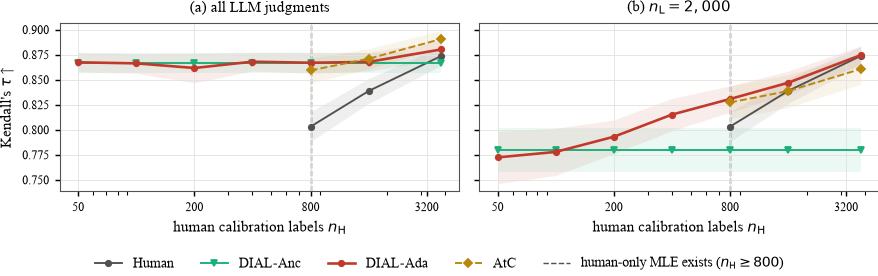

In [3]:

# AtC aggregates the same human comparisons by the same pooled BTL, so it is drawn under the
# human-only display rule: only where that fit is finite in all 50 splits.
BTL_GATED = {"human_only", ATC}
CALIBRATION_METHODS = METHODS + [(ATC, LABEL[ATC], STYLE[ATC]["color"], STYLE[ATC]["ls"], STYLE[ATC]["marker"])]
HUMAN_EXISTS_LABEL = r"human-only MLE exists ($n_{{\mathrm{{H}}}}\geq{:,}$)"


def calibration_figure(ds=CALIBRATION_DATASET, panel=CALIBRATION_PANEL):
    """Main-text figure: human-label efficiency and the anchor--adapt crossover in Kendall's tau.

    (a) the collected LLM judgments of the full judge panel, (b) the same panel at the
    intermediate LLM budget, both against the human calibration budget on one shared y axis.
    """
    keep = human_exists_budgets(ds)
    n_star = min(keep)   # smallest budget at which the unrestricted human MLE exists in every split
    rows = calibration_rows(summary, intermediate, ds=ds, panel=panel)
    titles = ["(a) all LLM judgments", f"(b) $n_{{\\mathrm{{L}}}}={INTERMEDIATE_NL[ds]:,}$"]
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.05), sharey=True)
    for ax, frame, title in zip(axes, rows, titles):
        g0 = frame[(frame.dataset == ds) & (frame.panel == panel)]
        for method, label, color, ls, marker in CALIBRATION_METHODS:
            g = g0[g0.method == method].sort_values("n_H")
            if method in BTL_GATED:
                g = g[g.n_H.round().isin(keep)]
            if g.empty:
                continue
            lw = 1.45 if method == "dial_mu" else 1.05
            ax.plot(g.n_H, g.tau, color=color, ls=ls, marker=marker, ms=3, lw=lw, label=label)
            ax.fill_between(g.n_H, g.tau - 1.96 * g.tau_se, g.tau + 1.96 * g.tau_se,
                            color=color, alpha=.085, lw=0)
        # The human MLE exists above n_star regardless of the LLM budget, so the same line is
        # drawn in both panels; left of it the human-only fit is the bounded maximizer and is not
        # plotted.
        ax.axvline(n_star, color=STYLE["human_only"]["color"], ls="--", lw=.8, zorder=1,
                   label="_nolegend_" if ax is not axes[0] else HUMAN_EXISTS_LABEL.format(n_star))
        ax.set_xscale("log")
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks(XTICKS[ds])
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.set_xlabel(r"human calibration labels $n_{\mathrm{H}}$")
        ax.set_title(title, fontsize=8.5)
        ax.grid(color=GRID, lw=.5)
        ax.tick_params(length=2.5, labelsize=6.5)
    axes[0].set_ylabel(r"Kendall's $\tau$")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False, bbox_to_anchor=(.5, -.12))
    mark_better(axes[0], "up")   # before the layout, so the glyph is measured with the label
    fig.tight_layout()
    return fig


print("human budgets with a finite MLE in every split:", sorted(human_exists_budgets()))
with plt.rc_context(RCPARAMS):
    fig = calibration_figure()
    fig.savefig(FIG_DIR / "fig_real_calibration.pdf", bbox_inches="tight", dpi=300, pad_inches=0)
    plt.show()

## Figure 10 (appendix): human budget at the collected LLM data

Where the small panel does and does not close the gap to `large6`, `all`, and human-only.


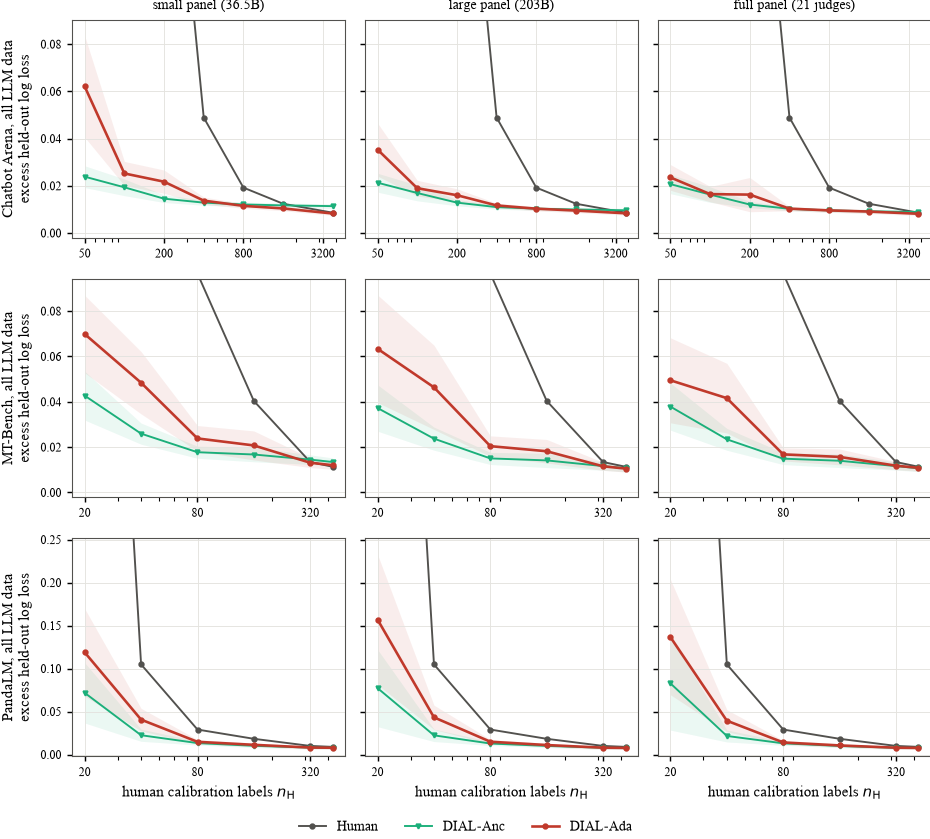

In [4]:
show("fig_panel_human_budget")

## Figure 11 (appendix): LLM budget at a fixed human budget

The reverse constraint: an imprecise LLM-only direction limits DIAL-Anc, while DIAL-Ada ($\mu$) can re-estimate $\mu$ from the human comparisons.


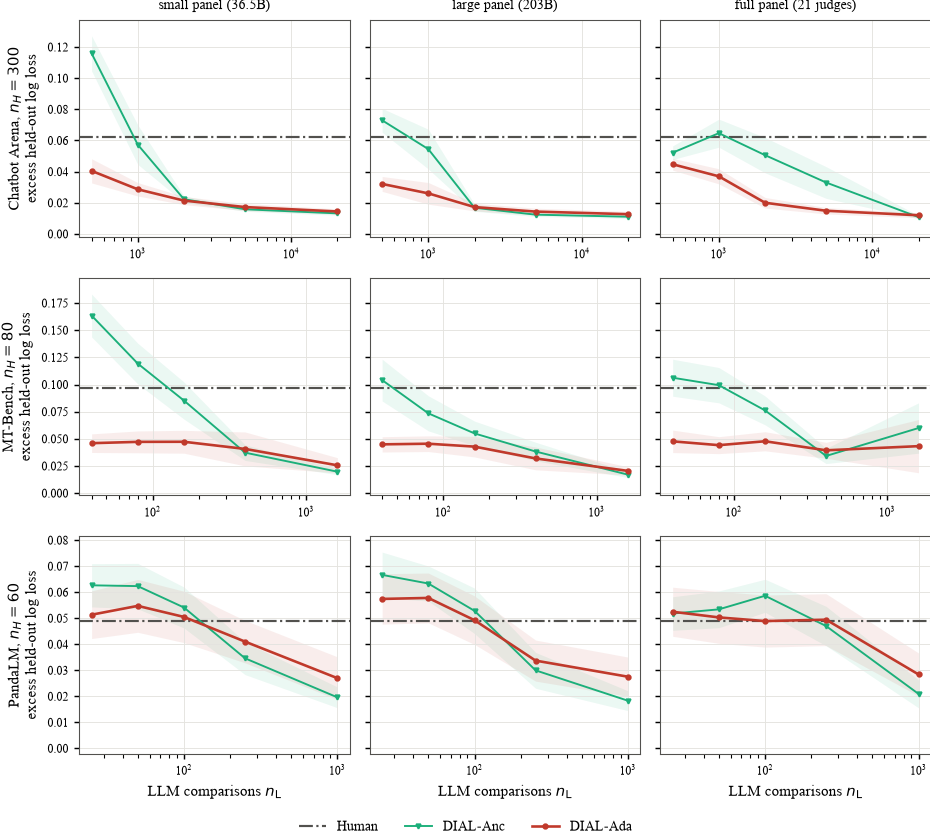

In [5]:
show("fig_panel_llm_budget")

## Figure 12 (appendix): human budget at a fixed intermediate LLM budget

The middle LLM level of sweep 2, where keeping the LLM-only consensus direction (DIAL-Anc) and letting human comparisons update it (DIAL-Ada) cross over.


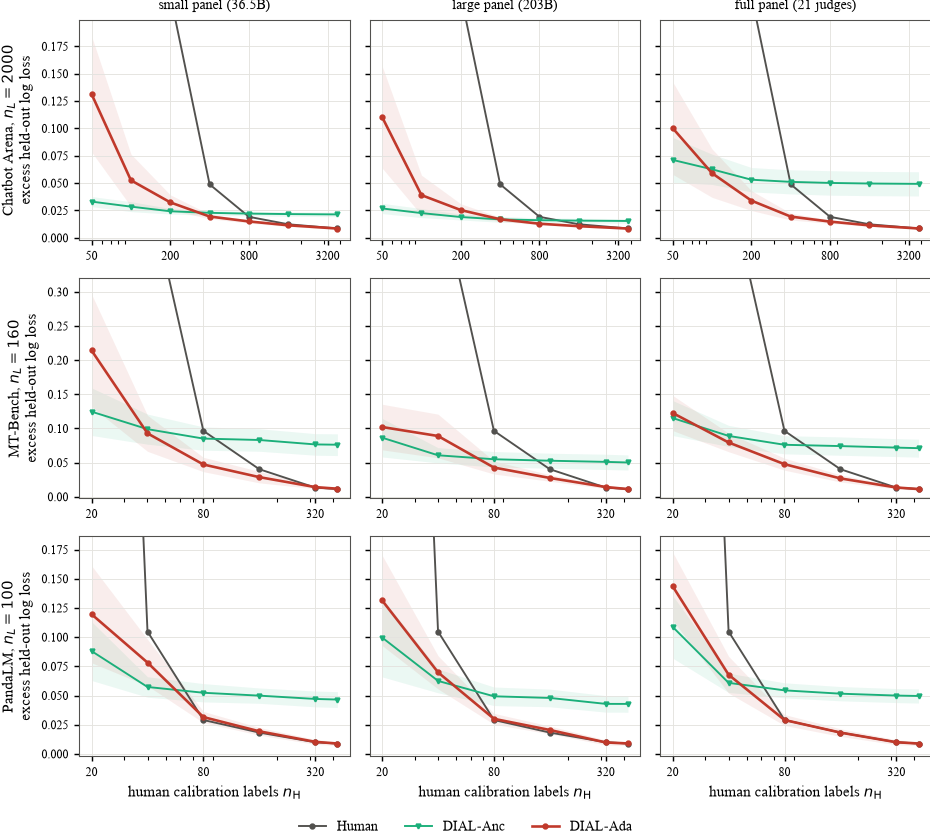

In [6]:
show("fig_panel_intermediate_llm")

## Full-pool comparison in both metrics

DIAL-$\mu$ against Cons-Cal at the largest tested human budget: the log-loss ratio, the
$\tau$ gain, and whether each beats Cons-Cal by more than two paired Monte Carlo standard
errors.

In [7]:
rows = []
for (ds, panel), g in intermediate.groupby(["dataset", "panel"]):
    top = g[g.n_H == g.n_H.max()].set_index("method")
    rows.append(dict(dataset=ds, panel=panel, n_H=round(g.n_H.max()),
                     loss_cons=top.loc["consensus_cal", "excess"], loss_dial=top.loc["dial_mu", "excess"],
                     loss_ratio=top.loc["consensus_cal", "excess"] / top.loc["dial_mu", "excess"],
                     tau_cons=top.loc["consensus_cal", "tau"], tau_dial=top.loc["dial_mu", "tau"],
                     tau_gain=top.loc["dial_mu", "tau"] - top.loc["consensus_cal", "tau"],
                     loss_signif=bool(top.loc["dial_mu", "delta_vs_cons"]
                                      < -2 * top.loc["dial_mu", "paired_mcse"])))
pd.DataFrame(rows).round(4)

,dataset,panel,n_H,loss_cons,loss_dial,loss_ratio,tau_cons,tau_dial,tau_gain,loss_signif
0,arena_33k,all,3802,0.0493,0.0086,5.7502,0.7796,0.8745,0.0949,True
1,arena_33k,large6,3802,0.0154,0.0085,1.8125,0.8234,0.8726,0.0493,True
2,arena_33k,small6,3802,0.0214,0.0085,2.5153,0.7808,0.8747,0.0939,True
3,mt_bench,all,422,0.0712,0.0113,6.2858,0.6773,0.8747,0.1973,True
4,mt_bench,large6,422,0.0502,0.0113,4.4544,0.7867,0.8827,0.0960,True
5,mt_bench,small6,422,0.0762,0.0118,6.4506,0.7200,0.8907,0.1707,True
6,pandalm,all,421,0.0496,0.0089,5.5813,0.3840,0.8280,0.4440,True
7,pandalm,large6,421,0.0428,0.0089,4.7919,0.4520,0.8400,0.3880,True
8,pandalm,small6,421,0.0466,0.0089,5.2477,0.4120,0.8360,0.4240,True


## Descriptive crossover locations

The first tested human budget at which DIAL-$\mu$ beats Cons-Cal by more than two paired Monte
Carlo standard errors, and keeps doing so at every higher budget (appendix Table 3). A post hoc
summary of these curves, not a calibrated test or a switching rule for new data.

In [8]:
def crossover(frame):
    out = []
    for (ds, panel), g in frame.groupby(["dataset", "panel"]):
        g = g[g.method == "dial_mu"].sort_values("n_H").set_index("n_H")
        better = g.delta_vs_cons < -2 * g.paired_mcse
        first = next((n for n in better.index if better.loc[n:].all()), None)
        out.append(dict(dataset=ds, panel=panel, n_L=INTERMEDIATE_NL[ds], crossover_n_H=first))
    return pd.DataFrame(out)

crossover(intermediate).pivot(index="dataset", columns="panel", values="crossover_n_H")

panel,all,large6,small6
dataset,,,
arena_33k,200.0,800.0,400.0
mt_bench,80.0,160.0,80.0
pandalm,80.0,80.0,80.0
